# LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict


In [60]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [69]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [82]:
def train_decision_tree(X_train, y_train, X_test,
                        n_iter=400, n_splits=10, random_state=0):

    # ── 1. Search space ───────────────────────────────────────────────────────
    param_list = {
        'max_depth':         list(np.arange(2, 50)),
        'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
        'min_samples_leaf':  [5, 10, 20, 30, 50, 100, 150],
        'criterion':         ['gini', 'entropy']
    }

    # ── 2. Random search ──────────────────────────────────────────────────────
    random_search = RandomizedSearchCV(
        DecisionTreeClassifier(),
        param_distributions=param_list,
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        n_jobs=-1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state,
    )
    random_search.fit(X_train, y_train)

    # ── 3. Best model ─────────────────────────────────────────────────────────
    best_model = random_search.best_estimator_
    best_model.fit(X_train, y_train)

    # ── 4. Predict ────────────────────────────────────────────────────────────
    y_pred  = best_model.predict(X_test)
    y_score = best_model.predict_proba(X_test)   # ← shape (n_samples, n_classes)

    # ── 5. Collect all attributes ─────────────────────────────────────────────
    info = {
        # best model and params
        'best_model':           best_model,
        'best_params':          random_search.best_params_,
        'best_cv_score':        random_search.best_score_,

        # tree structure
        'n_features':           best_model.n_features_in_,
        'feature_importances':  best_model.feature_importances_,
        'n_classes':            best_model.n_classes_,
        'classes':              best_model.classes_,
        'tree_depth':           best_model.get_depth(),
        'n_leaves':             best_model.get_n_leaves(),

        # search details
        'n_iter':               n_iter,
        'n_splits':             n_splits,
        'cv_results':           random_search.cv_results_,
    }

    # ── 6. Print summary ──────────────────────────────────────────────────────
    print("="*55)
    print("DECISION TREE — TRAINING SUMMARY")
    print("="*55)
    print(f"  Best params       : {info['best_params']}")
    print(f"  Best CV score     : {info['best_cv_score']:.4f}")
    print(f"  Tree depth        : {info['tree_depth']}")
    print(f"  Number of leaves  : {info['n_leaves']}")
    print(f"  Features used     : {info['n_features']}")
    print(f"  Classes           : {info['classes']}")
    print(f"  y_score shape     : {y_score.shape}")   # (n_samples, n_classes)
    print("="*55)

    return y_pred, y_score, info          # ← added y_score here


# READ DATAFRAME

In [2]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [3]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,5,0,16.877316,46.000,50.800000,82.152821,4.611111,17.883041,6.500000,2.0,2.668550,1492.000000,41.586230,9.213770,1.0,19.541300,32.690900,2.0
1,1,9,0,14.035590,48.000,46.000000,90.666667,8.000000,18.204545,11.000000,2.0,2.579490,1498.650000,42.029150,3.970850,1.0,15.410700,27.055200,0.0
2,2,10,1,16.648696,56.500,75.600000,82.333333,27.000000,12.450000,10.000000,3.0,3.389932,1796.890000,59.788250,15.811750,2.0,25.634700,42.380000,0.0
3,3,9,0,18.292347,56.000,81.600000,79.000000,23.000000,18.204545,7.000000,3.0,3.841910,1923.440000,62.775700,18.824300,2.0,26.479800,45.996600,1.0
4,4,18,1,17.937682,54.626,76.139461,90.152104,12.000000,26.463732,8.003205,3.0,12.054014,2652.510000,60.327711,15.811750,2.0,29.912400,42.380000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8377,8455,7,1,16.130585,46.070,48.700252,81.861037,6.500000,18.075000,7.000000,1.0,2.625946,1490.847845,45.526276,3.173977,1.0,18.024600,31.583004,0.0
8378,8456,10,1,17.300000,56.130,77.531978,79.833333,8.500000,13.575000,5.000000,3.0,4.987853,1678.330810,69.880763,7.651215,1.0,22.983200,36.475662,1.0
8379,8457,10,1,40.937571,49.560,143.030726,82.166667,21.500000,16.840263,9.500000,4.0,3.990512,1547.346725,107.979706,35.051020,2.0,31.594712,35.106855,0.0
8380,8458,15,1,22.500000,63.790,130.236404,88.395702,10.000000,26.417470,10.500000,2.0,4.967841,1674.735823,103.517750,26.718654,2.0,46.467581,57.530686,2.0


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scl = StandardScaler()

features = [
    'Basic_Demos-Age', 'Basic_Demos-Sex', 'Physical-BMI',
    'Physical-Height', 'Physical-Weight', 'Physical-MAP_CAL',
    'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL',
    'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
    'BIA-BIA_FFM', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
    'BIA-BIA_TBW'
]

df[features] = scl.fit_transform(df[features])

In [5]:
#df=df[(df['sii']!=3)|(df['sii']!=2)].copy()

In [6]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])


# Data Preparation

In [7]:
X.shape

(8382, 17)

In [8]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5794, 1567,  936,   85], dtype=int64))

In [9]:
Counter(y)

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

In [10]:
ctr = Counter(y)
ctr

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

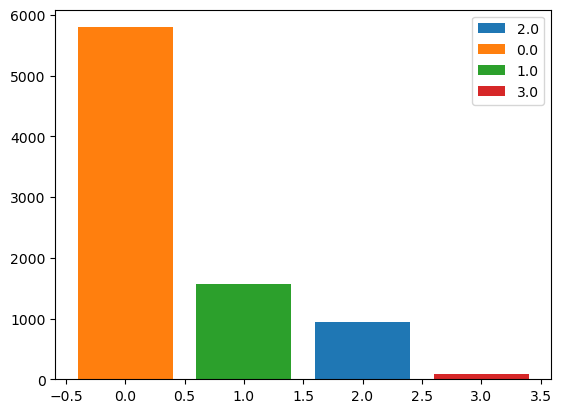

In [11]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange','tab:green','tab:red'])
plt.legend()
plt.show()

## Data Partitioning

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [14]:
X_train.shape

(5867, 17)

In [15]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2., 3.]), array([4056, 1097,  655,   59], dtype=int64)),
 (array([0., 1., 2., 3.]), array([1738,  470,  281,   26], dtype=int64)))

In [16]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.6913243565706494

## Classification

In [61]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scikitplot.metrics import plot_roc

In [62]:
from sklearn.tree import DecisionTreeClassifier

In [63]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_cl_sii = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=10, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=400,
)

random_search.fit(X_train, y_train)
dt_cl_sii = random_search.best_estimator_

In [64]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.2, 'min_samples_leaf': 30, 'max_depth': 3, 'criterion': 'entropy'} 0.6913332674384124


In [66]:
dt_cl_sii = random_search.best_estimator_
dt_cl_sii.fit(X_train, y_train)
y_pred0 = dt_cl_sii.predict(X_test)

In [67]:
print('Accuracy %s' % accuracy_score(y_test, y_pred0))
print('F1-score %s' % f1_score(y_test, y_pred0, average=None))
print(classification_report(y_test, y_pred0))

Accuracy 0.6910536779324056
F1-score [0.81730543 0.         0.         0.        ]
              precision    recall  f1-score   support

         0.0       0.69      1.00      0.82      1738
         1.0       0.00      0.00      0.00       470
         2.0       0.00      0.00      0.00       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.69      2515
   macro avg       0.17      0.25      0.20      2515
weighted avg       0.48      0.69      0.56      2515



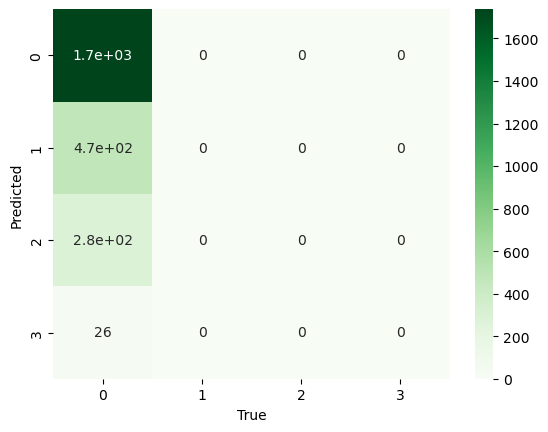

In [70]:
cf = confusion_matrix(y_test, y_pred0)
sns.heatmap(cf, annot=True, cmap="Greens")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

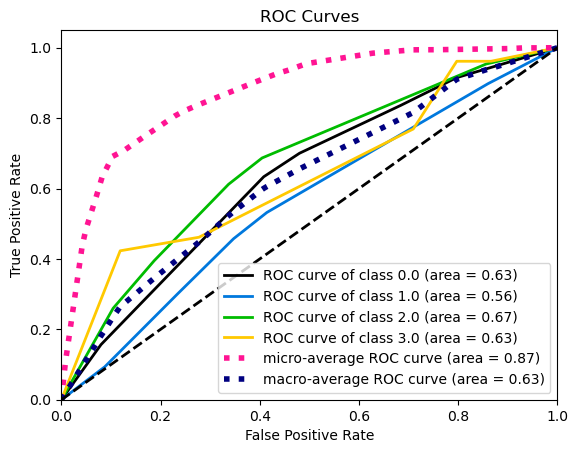

In [71]:
y_score = dt_cl_sii.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

## PCA

In [72]:
from sklearn.decomposition import PCA

In [73]:
def plot_pca(X_pca, y_train):
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolor='k', alpha=0.7)
    plt.show()

In [74]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train)
print(X_train.shape, X_pca.shape)

(5867, 17) (5867, 2)


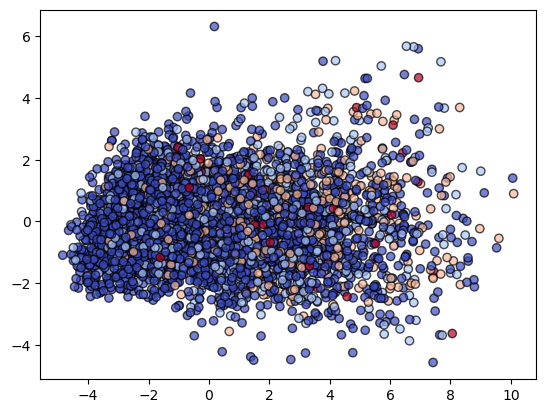

In [75]:
plot_pca(X_pca, y_train)

# Oversampling

In [25]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

### RandomOverSampler

In [76]:
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1.0: 4056, 0.0: 4056, 2.0: 4056, 3.0: 4056})


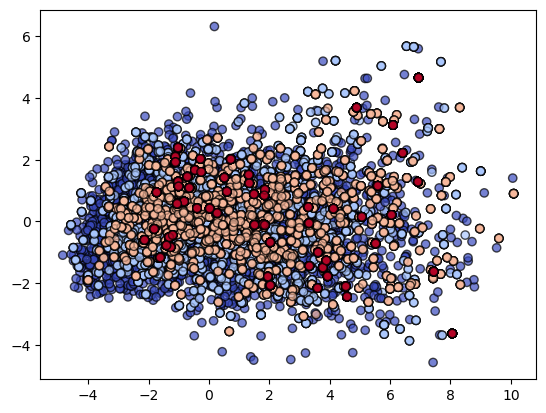

In [77]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [ ]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['feature_importances'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 48, 'criterion': 'entropy'}
  Best CV score     : 0.7914
  Tree depth        : 22
  Number of leaves  : 700
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 48, 'criterion': 'entropy'}
[0.07065976 0.01151687 0.0744601  0.1266927  0.06787799 0.05224024
 0.06325684 0.07078785 0.04222925 0.02093199 0.09951055 0.07920371
 0.03966922 0.07082387 0.01015785 0.03776764 0.06221357]
0.7913577025085604


Accuracy 0.4628230616302187
F1-score [0.62809917 0.22463768 0.21419976 0.02857143]
              precision    recall  f1-score   support

         0.0       0.74      0.55      0.63      1738
         1.0       0.20      0.26      0.22       470
         2.0       0.16      0.32      0.21       281
         3.0       0.02      0.04      0.03        26

    accuracy                           0.46      2515
   macro avg       0.28      0.29      0.27      2515
weighted avg       0.56      0.46      0.50      2515



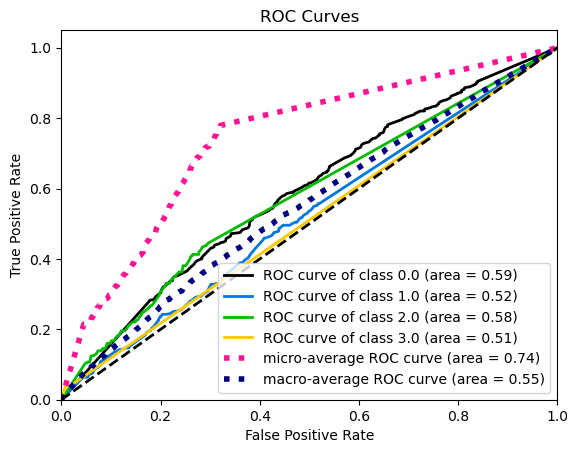

In [84]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

plot_roc(y_test, y_score)
plt.show()



### SMOTE

In [85]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1.0: 4056, 0.0: 4056, 2.0: 4056, 3.0: 4056})


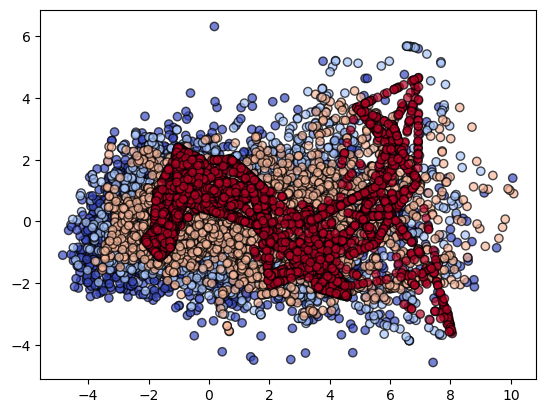

In [86]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [87]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['feature_importances'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 24, 'criterion': 'entropy'}
  Best CV score     : 0.6980
  Tree depth        : 23
  Number of leaves  : 777
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 24, 'criterion': 'entropy'}
[0.21895008 0.04936952 0.04171865 0.0602318  0.04624772 0.04655436
 0.03635442 0.03937689 0.06461053 0.0827223  0.05496786 0.07063533
 0.04121475 0.03422842 0.0165371  0.04544005 0.05084023]
0.6980374213771972


Accuracy 0.5284294234592445
F1-score [0.69499241 0.24852071 0.17981073 0.02298851]
              precision    recall  f1-score   support

         0.0       0.74      0.66      0.69      1738
         1.0       0.23      0.27      0.25       470
         2.0       0.16      0.20      0.18       281
         3.0       0.02      0.04      0.02        26

    accuracy                           0.53      2515
   macro avg       0.29      0.29      0.29      2515
weighted avg       0.57      0.53      0.55      2515



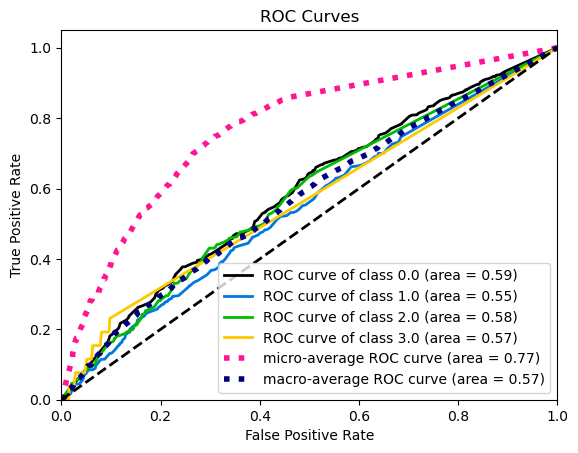

In [88]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


### ADASYN

In [93]:
ada = ADASYN(random_state=42)
X_res, y_res = ada.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({3.0: 4074, 2.0: 4062, 0.0: 4056, 1.0: 3983})


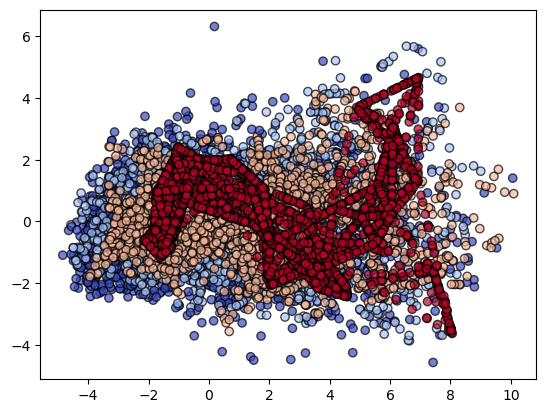

In [94]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [95]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['feature_importances'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 24, 'criterion': 'entropy'}
  Best CV score     : 0.6786
  Tree depth        : 24
  Number of leaves  : 759
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 24, 'criterion': 'entropy'}
[0.19712091 0.03929606 0.04188979 0.05920869 0.04055017 0.05993987
 0.05207856 0.03547913 0.0513844  0.0799677  0.06263545 0.05644732
 0.04452303 0.04923929 0.01430987 0.05651749 0.0594123 ]
0.6785782320569536


Accuracy 0.4783300198807157
F1-score [0.65037594 0.20498084 0.16714697 0.        ]
              precision    recall  f1-score   support

         0.0       0.71      0.60      0.65      1738
         1.0       0.19      0.23      0.20       470
         2.0       0.14      0.21      0.17       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.48      2515
   macro avg       0.26      0.26      0.26      2515
weighted avg       0.54      0.48      0.51      2515



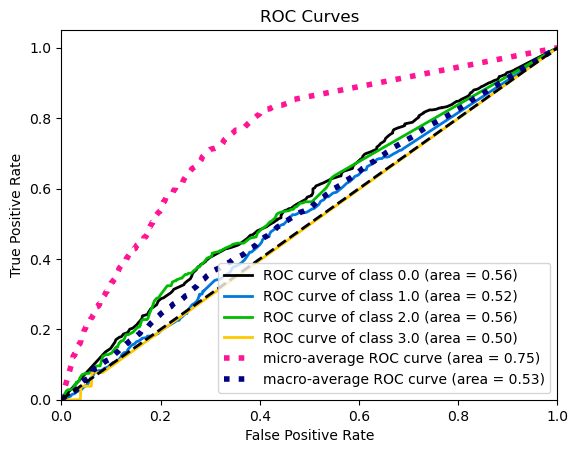

In [96]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


# Undersampling

In [97]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours

### RandomUnderSampler

In [100]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 59, 1.0: 59, 2.0: 59, 3.0: 59})


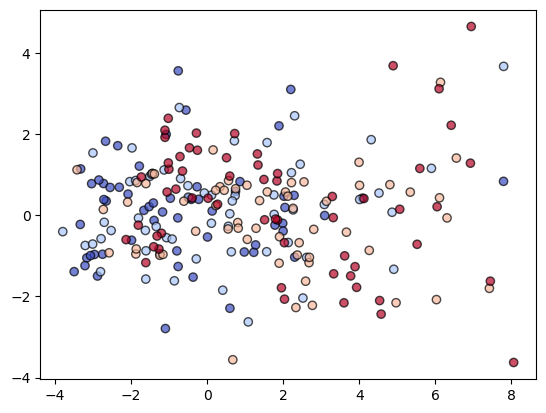

In [101]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [102]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.2, 'min_samples_leaf': 10, 'max_depth': 32, 'criterion': 'gini'}
  Best CV score     : 0.4020
  Tree depth        : 6
  Number of leaves  : 9
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.2, 'min_samples_leaf': 10, 'max_depth': 32, 'criterion': 'gini'}
0.4019927536231885


Accuracy 0.3836978131212724
F1-score [0.52975048 0.24019608 0.25203252 0.03686636]
              precision    recall  f1-score   support

         0.0       0.80      0.40      0.53      1738
         1.0       0.19      0.31      0.24       470
         2.0       0.18      0.44      0.25       281
         3.0       0.02      0.15      0.04        26

    accuracy                           0.38      2515
   macro avg       0.30      0.33      0.26      2515
weighted avg       0.61      0.38      0.44      2515



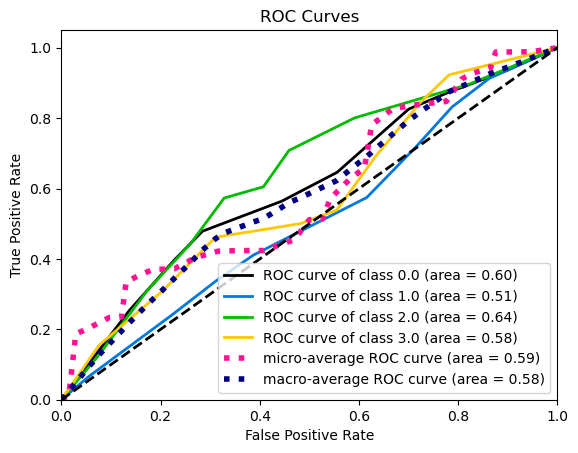

In [103]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


### CondensedNearestNeighbour

In [104]:
import warnings
warnings.simplefilter("ignore")

In [105]:
cnn = CondensedNearestNeighbour(random_state=42, n_jobs=10)
X_res, y_res = cnn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 397, 1.0: 244, 2.0: 207, 3.0: 59})


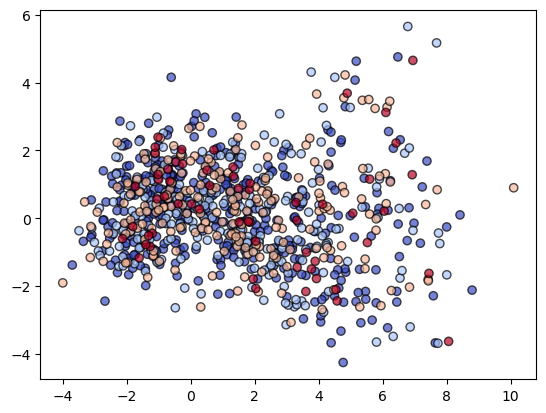

In [106]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [107]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.002, 'min_samples_leaf': 150, 'max_depth': 46, 'criterion': 'entropy'}
  Best CV score     : 0.4411
  Tree depth        : 4
  Number of leaves  : 5
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.002, 'min_samples_leaf': 150, 'max_depth': 46, 'criterion': 'entropy'}
0.44113553113553117


Accuracy 0.6910536779324056
F1-score [0.81730543 0.         0.         0.        ]
              precision    recall  f1-score   support

         0.0       0.69      1.00      0.82      1738
         1.0       0.00      0.00      0.00       470
         2.0       0.00      0.00      0.00       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.69      2515
   macro avg       0.17      0.25      0.20      2515
weighted avg       0.48      0.69      0.56      2515



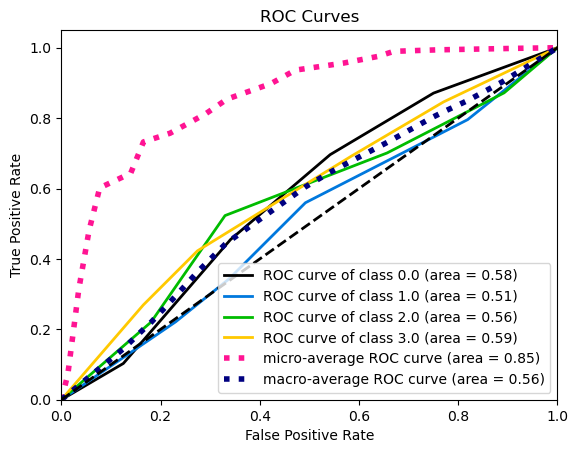

In [108]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()



### Tomek Links

In [109]:
tl = TomekLinks()
X_res, y_res = tl.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 3642, 1.0: 775, 2.0: 444, 3.0: 59})


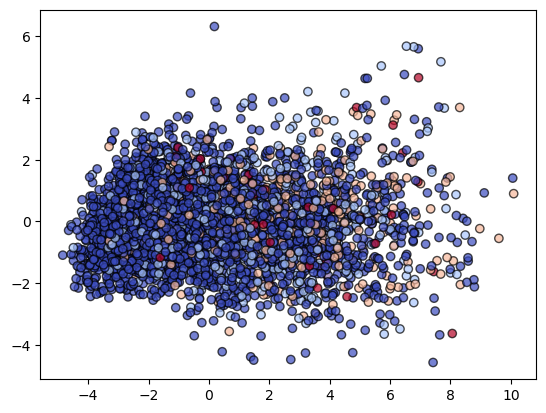

In [110]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [111]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.2, 'min_samples_leaf': 5, 'max_depth': 43, 'criterion': 'entropy'}
  Best CV score     : 0.7404
  Tree depth        : 7
  Number of leaves  : 10
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.2, 'min_samples_leaf': 5, 'max_depth': 43, 'criterion': 'entropy'}
0.7404471544715447


Accuracy 0.6910536779324056
F1-score [0.81730543 0.         0.         0.        ]
              precision    recall  f1-score   support

         0.0       0.69      1.00      0.82      1738
         1.0       0.00      0.00      0.00       470
         2.0       0.00      0.00      0.00       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.69      2515
   macro avg       0.17      0.25      0.20      2515
weighted avg       0.48      0.69      0.56      2515



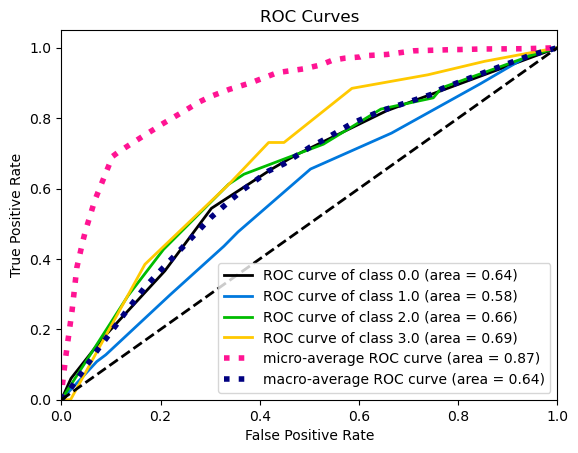

In [112]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()



### Edited Nearest Neighbors

In [113]:
enn = EditedNearestNeighbours()
X_res, y_res = enn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 1685, 3.0: 59, 1.0: 17, 2.0: 4})


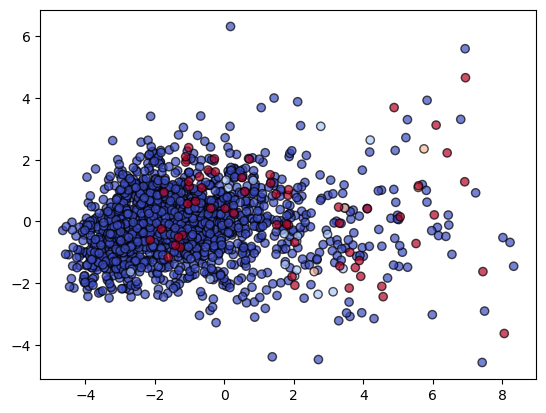

In [114]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [115]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.05, 'min_samples_leaf': 20, 'max_depth': 19, 'criterion': 'entropy'}
  Best CV score     : 0.9552
  Tree depth        : 7
  Number of leaves  : 15
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.05, 'min_samples_leaf': 20, 'max_depth': 19, 'criterion': 'entropy'}
0.9552291987673345


Accuracy 0.6910536779324056
F1-score [0.81730543 0.         0.         0.        ]
              precision    recall  f1-score   support

         0.0       0.69      1.00      0.82      1738
         1.0       0.00      0.00      0.00       470
         2.0       0.00      0.00      0.00       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.69      2515
   macro avg       0.17      0.25      0.20      2515
weighted avg       0.48      0.69      0.56      2515



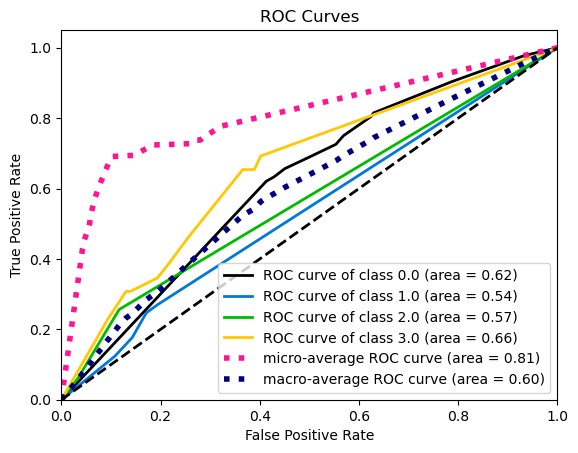

In [116]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


### Cluster Centroids

In [117]:
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import ClusterCentroids

In [118]:
cc = ClusterCentroids(
    estimator=MiniBatchKMeans(n_init=1, random_state=0), random_state=42
)
X_res, y_res = cc.fit_resample(X, y)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 85, 1.0: 85, 2.0: 85, 3.0: 85})


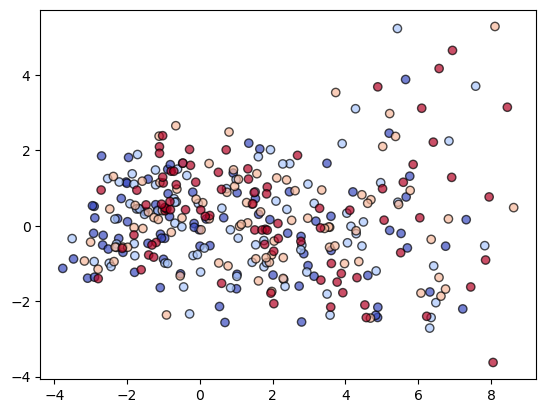

In [119]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [120]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.1, 'min_samples_leaf': 5, 'max_depth': 14, 'criterion': 'entropy'}
  Best CV score     : 0.4529
  Tree depth        : 8
  Number of leaves  : 20
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.1, 'min_samples_leaf': 5, 'max_depth': 14, 'criterion': 'entropy'}
0.45294117647058824


Accuracy 0.28151093439363817
F1-score [0.48892405 0.01214575 0.18975904 0.03571429]
              precision    recall  f1-score   support

         0.0       0.78      0.36      0.49      1738
         1.0       0.12      0.01      0.01       470
         2.0       0.16      0.22      0.19       281
         3.0       0.02      0.92      0.04        26

    accuracy                           0.28      2515
   macro avg       0.27      0.38      0.18      2515
weighted avg       0.58      0.28      0.36      2515



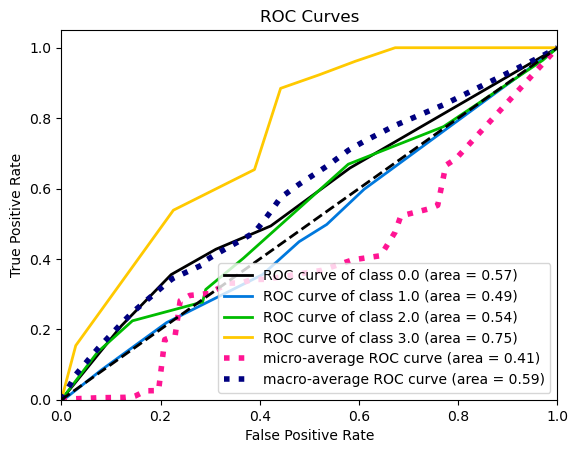

In [121]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


# MIX

In [122]:
df_over=df[df['sii'].isin([1,2,3])]

In [123]:

attributes = [col for col in df_over.columns if col != 'sii']
X_ov = df_over[attributes].values
y_ov = np.array(df_over['sii'])

In [ ]:
X_train_ov, X_test_ov, y_train_ov, y_test_ov = train_test_split(X_ov, y_ov, test_size=0.3, random_state=100, stratify=y_ov)

In [125]:
np.unique(y_train_ov, return_counts=True), np.unique(y_test_ov, return_counts=True)

((array([1., 2., 3.]), array([1097,  655,   59], dtype=int64)),
 (array([1., 2., 3.]), array([470, 281,  26], dtype=int64)))

### ADASYN

In [126]:
ada = ADASYN(random_state=42)
X_res, y_res = ada.fit_resample(X_train_ov, y_train_ov)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({2.0: 1136, 3.0: 1112, 1.0: 1097})


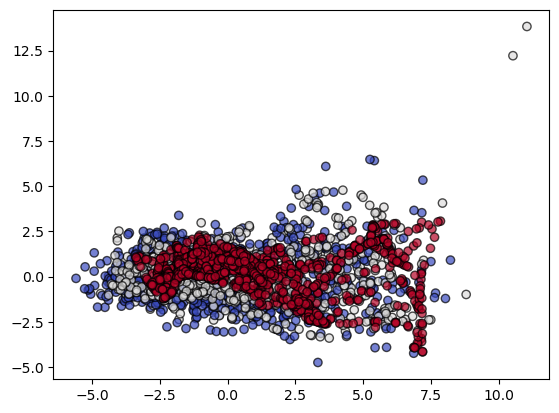

In [127]:
pca = PCA(n_components=2)
pca.fit(X_train_ov)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [128]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test_ov)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 18, 'criterion': 'entropy'}
  Best CV score     : 0.6580
  Tree depth        : 18
  Number of leaves  : 350
  Features used     : 17
  Classes           : [1. 2. 3.]
  y_score shape     : (777, 3)
{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 18, 'criterion': 'entropy'}
0.6580078648672804


Accuracy 0.4491634491634492
F1-score [0.55707763 0.34915254 0.04545455]
              precision    recall  f1-score   support

         1.0       0.60      0.52      0.56       470
         2.0       0.33      0.37      0.35       281
         3.0       0.03      0.08      0.05        26

    accuracy                           0.45       777
   macro avg       0.32      0.32      0.32       777
weighted avg       0.49      0.45      0.46       777



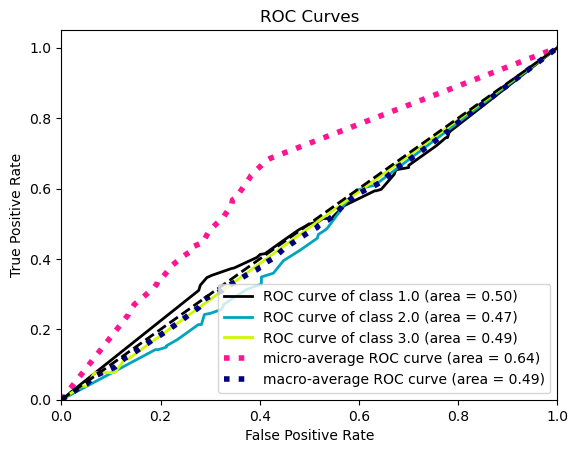

In [129]:
# predict
print('Accuracy %s' % accuracy_score(y_test_ov, y_pred))
print('F1-score %s' % f1_score(y_test_ov, y_pred, average=None))
print(classification_report(y_test_ov, y_pred))

# roc
plot_roc(y_test_ov, y_score)
plt.show()
